# [*Problema do caixeiro viajante*](http://en.wikipedia.org/wiki/Traveling_salesman_problem) (TSP):

> *Dado um conjunto de cidades e as distâncias entre cada par de cidades, encontre um **tour** das cidades com a distância total mínima. Um **tour** significa que você começa em uma cidade, visita todas as outras cidades exatamente uma vez e depois retorna à cidade inicial.*

- Este notebook se baseia no [Notebook IPython sobre o problema do caixeiro viajante] de [Peter Norvig](http://norvig.com/)(http://nbviewer.ipython.org/url/norvig.com/ipython/TSPv3 .ipynb).
- Mostrarei como aplicar algoritmos evolutivos para resolver o TSP.

- Este é um problema [*intratável*](http://en.wikipedia.org/wiki/Intractability_(complexity) bem conhecido, o que significa que não existem soluções eficientes que funcionem para um grande número de cidades.
- Podemos criar um algoritmo ineficiente que funcione bem para um pequeno número de citações (cerca de uma dúzia).
- Também podemos encontrar um passeio *quase* mais curto por milhares de cidades.
- Na verdade, o fato de não existir um algoritmo eficiente é libertador:
> **Isso significa que podemos usar um algoritmo muito simples e ineficiente e não nos sentirmos mal por isso.**

### O *vocabulário* do problema:

- **Cidade**: Para efeitos deste exercício, uma cidade é "atômica" no sentido de que não precisamos saber nada sobre os componentes ou atributos de uma cidade, apenas a que distância ela está de outras cidades.
- **Cidades**: Precisaremos representar um conjunto de cidades; O tipo de dados `set` do Python pode ser apropriado para isso.
- **Distância**: Precisaremos da distância entre duas cidades. Se `A` e `B` são cidades. Isso pode ser feito com uma função, `distance(A, B)`, ou com um dict, `distance[A][B]` ou `distance[A, B]`, ou com um array se `A` e `B` são índices inteiros. A distância resultante será um número real (que Python chama de `float`).
- **Tour**: Um tour é uma lista ordenada de cidades; Os tipos de dados `list` ou `tuple` do Python funcionariam.
- **Distância total**: soma das distâncias das cidades adjacentes no passeio. Provavelmente teremos uma função, `total_distance(tour)`.


Matriz de custos:
[[758 439 326 732]
 [217 403 218 628]
 [267 336 369 558]
 [806 139 172 987]]

Solução do TSP: ['x_(0,_2)', 'x_(1,_0)', 'x_(2,_3)', 'x_(3,_1)']

        # Custo: 1240.0
        # Cidades: 4
        # Arcos: [(0, 2), (2, 0), (1, 0), (0, 1), (2, 3), (3, 2), (3, 1), (1, 3)]
    

Caminho percorrido:
1º Carminho: 0 -> 2
2º Carminho: 2 -> 0
3º Carminho: 1 -> 0
4º Carminho: 0 -> 1
5º Carminho: 2 -> 3
6º Carminho: 3 -> 2
7º Carminho: 3 -> 1
8º Carminho: 1 -> 3


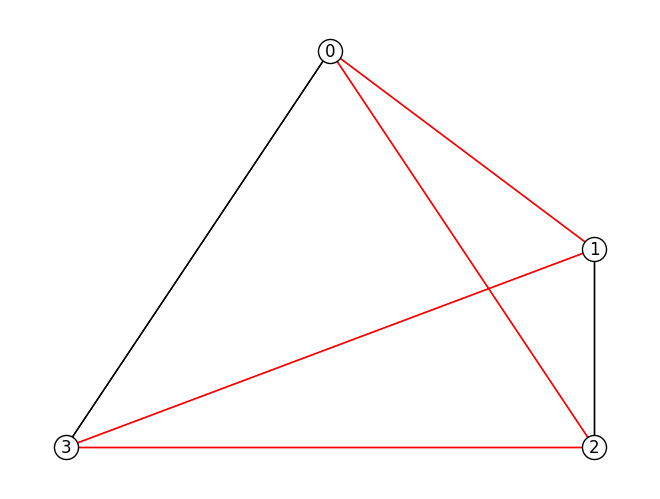

In [41]:
import numpy as np
import random
from pulp import *
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cmx
import pandas as pd

def format_rota(rota):
    cidades = []
    for cidade in rota:
        cidades.append(str(cidade[0]) + " -> " + str(cidade[1]))
    return ", ".join(cidades)

def format_rota_objeto(rota):
    cidades = []
    for i, cidade in enumerate(rota):
        cidades.append((f"{i + 1}º Carminho: {cidade[0]} -> {cidade[1]}" ))
    return cidades




class TSPProblem:

    def __init__(self, custo):
        self.custo = custo
        self.n = len(custo)
        self.arcos = [(i, j) for i in range(self.n) for j in range(self.n) if i != j]
        self.tsp = LpProblem("CaixeiroViajante", LpMinimize)

    def build_problem(self):
        # Variáveis de decisão
        x = LpVariable.dicts("x", self.arcos, cat="Binary")

        # Função objetivo
        self.tsp += lpSum([self.custo[i][j] * x[(i, j)] for (i, j) in self.arcos])

        # Restrições
        for i in range(self.n):
            self.tsp += lpSum([x[(i, j)] for j in range(self.n) if i != j]) == 1
            self.tsp += lpSum([x[(j, i)] for j in range(self.n) if i != j]) == 1

        # Resolver o problema
        self.tsp.solve()

    def get_solution(self):
        solucao = []
        for v in self.tsp.variables():
            if v.varValue > 0 and v.name.startswith("x"):
                solucao.append(v.name)
        return solucao

# Número de cidades
n_cidades = 4

# Gerar matriz de custos
custo = np.random.randint(100, 1000, size=(n_cidades, n_cidades))
print("\nMatriz de custos:")
print(custo)

# Substituir diagonal por um valor alto (sem conexão)
np.fill_diagonal(custo, 999)

# Resolver o problema TSP
tsp_problem = TSPProblem(custo)
tsp_problem.build_problem()

# Obter a solução
solucao = tsp_problem.get_solution()


# Criar o grafo
G = nx.Graph()

# Adicionar todos os arcos
G.add_edges_from(tsp_problem.arcos)

# Posição dos nós
coordenadas = [[2, 3], [3, 2], [3, 1], [1, 1], [1, 2]]

# Lista com os arcos atravessados pelo caixeiro
# Cria a lista de arcos
arcos_caminho = []
for var in tsp_problem.tsp.variables():
    if var.name[0] == "x":
        if var.varValue > 0:
                # Encontrando os indices para dividir a string
            open_parenthesis = var.name.find("(")
            close_parenthesis = var.name.find(")")
            comma = var.name.find(",")
            second_underline = var.name.find("_", comma)

                # Determinar (i,j)
            i = int(var.name[open_parenthesis + 1: comma])
            j = int(var.name[second_underline + 1: close_parenthesis])

            arcos_caminho.append((i, j))
            arcos_caminho.append((j, i))  # Simétrico

    # Imprime a solução
print(f"\nSolução do TSP: {solucao}")

    # Imprime uma docstring com os valores das variáveis usadas
print(f"""
        # Custo: {tsp_problem.tsp.objective.value()}
        # Cidades: {custo.shape[0]}
        # Arcos: {arcos_caminho}
    """)

print("\nCaminho percorrido:")
for linha in format_rota_objeto(arcos_caminho):
    print(linha)

# Identificando a cor dos arcos
cores = []
for arco in tsp_problem.arcos:
    if arco in arcos_caminho:
        cores.append("red")
    else:
        cores.append("black")

# Plotar o grafo
nx.draw(G, pos=coordenadas, with_labels=True, node_color="white",
        edgecolors="black", edgelist=tsp_problem.arcos, edge_color=cores)


O output do código apresentado resolve o problema do caixeiro viajante (TSP) para um problema com 4 cidades. A solução do problema é a seguinte:

O caixeiro começa na cidade 0.
Ele visita a cidade 2.
Ele visita a cidade 1.
Ele visita a cidade 3.
Ele retorna à cidade 0.

A matriz de custos mostra o custo de viajar entre cada par de cidades. A diagonal da matriz é preenchida com um valor alto para indicar que não é possível viajar para a mesma cidade duas vezes seguidas.

A lista de arcos mostra os arcos que fazem parte da solução do problema. Cada arco é representado por um par de números, onde o primeiro número é a cidade de origem e o segundo número é a cidade de destino.

A figura gerada mostra o grafo do problema com os arcos da solução em vermelho.

A solução apresentada é uma rota que visita cada cidade uma vez e tem o menor custo possível.

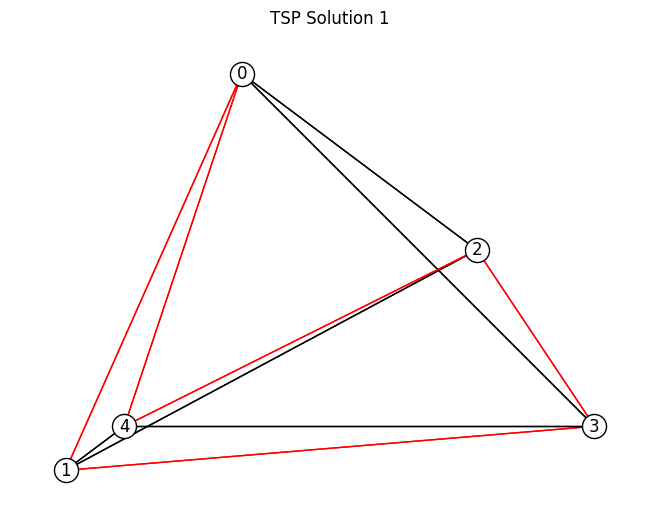

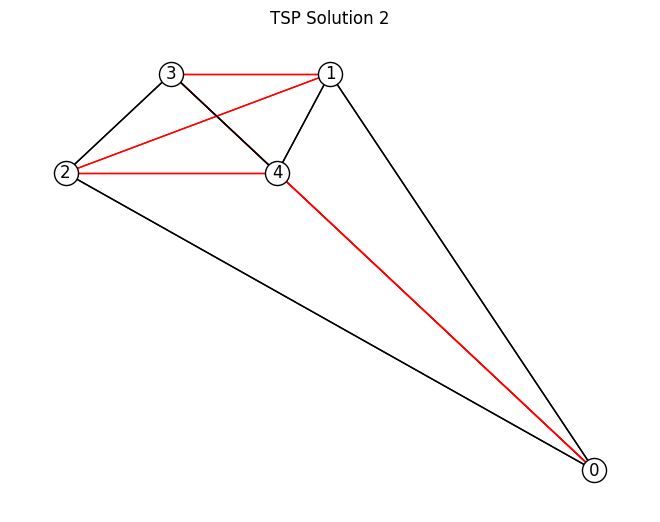

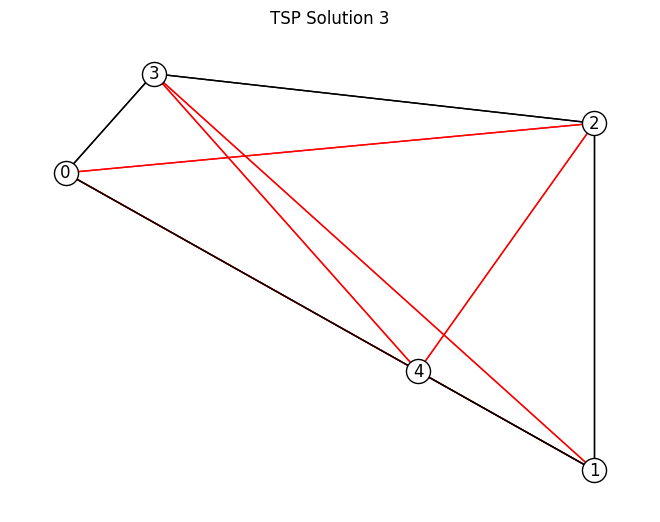

In [43]:
# Função para gerar cidades
def generate_cities(n):
    custo = np.random.randint(100, 1000, size=(n, n))
    np.fill_diagonal(custo, 999)
    return custo

# Função para plotar o gráfico
def plot_graph(arcos, arcos_caminho, coordenadas, title):
    G = nx.Graph()
    G.add_edges_from(arcos)
    cores = ["red" if arco in arcos_caminho or (arco[1], arco[0]) in arcos_caminho else "black" for arco in arcos]
    nx.draw(G, pos=coordenadas, with_labels=True, node_color="white", edgecolors="black", edgelist=arcos, edge_color=cores)
    plt.title(title)
    plt.show()


for instancia in range(1, 4):
    n_cidades = 5  # Número de cidades
    custo = generate_cities(n_cidades)
    tsp_problem = TSPProblem(custo)
    tsp_problem.build_problem()

    # Extrair os arcos da solução
    arcos_caminho = []
    for var in tsp_problem.tsp.variables():
        if var.varValue > 0 and var.name.startswith("x"):
            # Encontrando os índices para dividir a string
            open_parenthesis = var.name.find("(")
            close_parenthesis = var.name.find(")")
            comma = var.name.find(",")

            # Determinar (i, j)
            i = int(var.name[open_parenthesis+1: comma])
            j = int(var.name[comma+2: close_parenthesis])  # Ajuste aqui: pule o sublinhado
            
            arcos_caminho.append((i, j))

    # Coordenadas aleatórias para plotagem
    coordenadas = {i: (random.randint(0, 10), random.randint(0, 10)) for i in range(n_cidades)}

    # Lista completa de arcos
    arcos = tsp_problem.arcos

    # Plotar o gráfico
    plot_graph(arcos, arcos_caminho, coordenadas, f"TSP Solution {instancia}")



In [44]:
# Número de cidades
n_cidades = 4

# Custo real de viagem entre as cidades
# A matriz é simétrica se o custo de A para B é o mesmo de B para A
custo_real = [[999, 100, 200, 300],  # Custos de A para A, B, C, D
              [100, 999, 150, 250],  # Custos de B para A, B, C, D
              [200, 150, 999, 120],  # Custos de C para A, B, C, D
              [300, 250, 120, 999]]  # Custos de D para A, B, C, D

# Converter para numpy array para compatibilidade
custo = np.array(custo_real)

# Restante do código permanece o mesmo
tsp_problem = TSPProblem(custo)
tsp_problem.build_problem()

solucao = tsp_problem.get_solution()
print("\nSolução do TSP com custos reais:")
print(solucao)


Solução do TSP com custos reais:
['x_(0,_1)', 'x_(1,_0)', 'x_(2,_3)', 'x_(3,_2)']
